# Asymmetric-SQUID avoided-crossing fit

Minimal analysis used for the paper supplementary data. Peaks are found automatically only in the flux rows retained by the manual review.


## 1. Settings and approved flux rows


In [ ]:
"""Fit and plot the asymmetric-SQUID avoided crossing used in the paper."""

from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import least_squares
from scipy.signal import find_peaks


# Data and frequency calibration
HERE = Path.cwd()
if not (HERE / "data").is_dir():
    HERE = HERE / "avoided_crossing"
DATA_FILE = HERE / "data" / "16-37-55_QubitSpec_with_flux.hdf5"
FREQUENCY_CENTER_HZ = 5.5673450e9 + 50e6 - 0.09e6 - 0.28e6 / 4 + 300e6 + 300e6  # LO frequency used for the measurement

# Flux rows retained after the review. The value is the number of strongest local maxima to retain from that row; all other rows are omitted.
APPROVED_ROW_PEAK_COUNTS = {
    -0.185: 1, -0.190: 1, -0.195: 1, -0.200: 1, -0.205: 1,
    -0.210: 1, -0.215: 1, -0.220: 1, -0.225: 1, -0.230: 1,
    -0.235: 1, -0.240: 2, -0.245: 2, -0.255: 2, -0.260: 1,
    -0.265: 1, -0.270: 1,
}
SMOOTH_SIGMA = 1.5
BACKGROUND_SIGMA = 30.0
MIN_PEAK_DISTANCE = 6
MIN_PEAK_PROMINENCE = 0.8

# Avoided-crossing fit settings
EC_HZ = 0.013352e9
INITIAL_PARAMETERS = np.array([2.7, -0.134, 3.49, 86.7e9, 6.26e9, 34e6])
LOWER_BOUNDS = np.array([0.05, -10.0, 1.001, 1e6, 6.20e9, 0.05e6])
UPPER_BOUNDS = np.array([100.0, 10.0, 100.0, 1e12, 6.32e9, 100e6])
ROBUST_SCALE_HZ = 3e6

# Independent bare-SQUID calibration used to express the vertical axis as flux.
CAL_GAMMA = 4.141080094
CAL_EJ_SMALL_HZ = 10.710680e9
CAL_EC_HZ = 0.120000e9

# Final figure settings
FIGURE_SIZE = (12, 4)
FIGURE_DPI = 180
FONT = "Arial"
COLORMAP = "RdBu_r"
FIT_COLOR = "#202020"
BARE_COLOR = "white"
MODE_COLOR = "white"
SHOW_SELECTED_POINTS = False
SHOW_LEGEND = False
EXPORT_PDF = True
OUTPUT_PDF = HERE / "FAR_TLS_avoided_crossing_fit.pdf"

## 2. Read and plot the raw spectroscopy

The HDF5 file contains the repetition-averaged raw spectroscopy map. No filtering or background subtraction is applied before plotting.


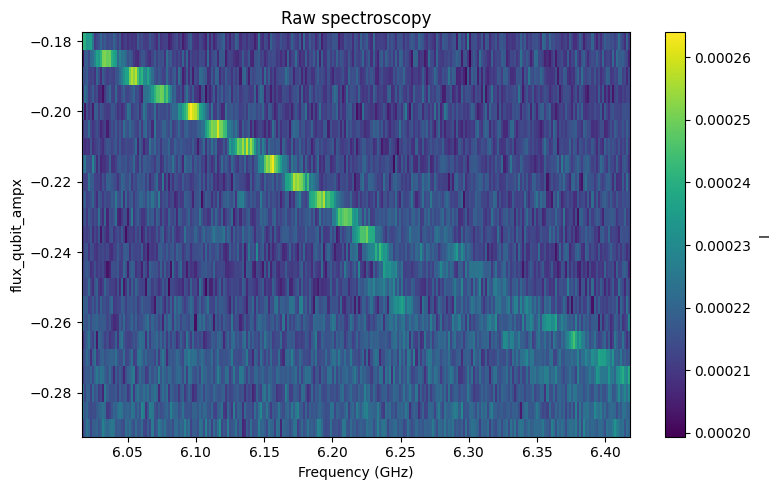

In [7]:
def load_data():
    """Read the repetition-averaged HDF5 datasets."""
    with h5py.File(DATA_FILE, "r") as h5:
        signal = h5["I"][:].astype(float)
        flux = h5["flux_qubit_ampx"][:].astype(float)
        frequency_hz = FREQUENCY_CENTER_HZ + h5["qubit_frequency"][:].astype(float)
    return flux, frequency_hz, signal

def plot_raw_data(flux, frequency_hz, signal):
    """Plot the repetition-averaged raw spectroscopy without preprocessing."""
    fig, ax = plt.subplots(figsize=(8, 5))
    mesh = ax.pcolormesh(frequency_hz / 1e9, flux, signal, shading="auto")
    fig.colorbar(mesh, ax=ax, label="I")
    ax.set(xlabel="Frequency (GHz)", ylabel="flux_qubit_ampx", title="Raw spectroscopy")
    fig.tight_layout()
    plt.show()

flux, frequency_hz, signal = load_data()
plot_raw_data(flux, frequency_hz, signal)


## 3. Avoided-crossing model

The bare qubit is modeled as a transmon formed by an asymmetric SQUID. Its flux-dependent transition frequency is

$$
f_q(\Phi)=\sqrt{8E_C E_{J,\mathrm{eff}}(\Phi)}-E_C,
$$

where all energies are expressed in frequency units and

$$
E_{J,\mathrm{eff}}(\Phi)=(\gamma+1)E_{J,\mathrm{small}}
\sqrt{\cos^2\theta+d^2\sin^2\theta},
\qquad
d=\frac{\gamma-1}{\gamma+1},
\qquad
\theta=\pi\frac{\Phi-\Phi_{\mathrm{offset}}}{P}.
$$

Here, $P$ is the flux-control period, $\Phi_{\mathrm{offset}}$ is its offset, $\gamma$ is the junction-energy ratio, and $E_{J,\mathrm{small}}$ is the smaller junction energy. The charging energy $E_C$ is held fixed.

The avoided crossing is described by the standard two-mode coupled Hamiltonian

$$
H/h=\begin{pmatrix}f_q(\Phi)&g\\g&f_m\end{pmatrix},
$$

where $f_m$ is the uncoupled mode frequency and $g$ is the coupling rate. Diagonalizing this matrix gives the two hybridized branches

$$
f_{\pm}(\Phi)=\frac{f_q(\Phi)+f_m}{2}
\pm\sqrt{\left[\frac{f_q(\Phi)-f_m}{2}\right]^2+g^2}.
$$

At resonance, $f_q=f_m$, the minimum branch separation is $2g$. The selected peaks are not assigned to a branch beforehand; each point contributes its distance to the nearer of $f_-$ and $f_+$. These nearest-branch residuals are minimized with a bounded robust least-squares fit using a `soft_l1` loss.


In [8]:
def find_approved_peaks(flux, frequency_hz, signal):
    """Find the strongest local maxima only in the approved flux rows."""
    selected_flux = []
    selected_frequency_hz = []

    for requested_flux, number_of_peaks in APPROVED_ROW_PEAK_COUNTS.items():
        row = int(np.argmin(np.abs(flux - requested_flux)))
        smooth = gaussian_filter1d(signal[row], SMOOTH_SIGMA)
        residual = smooth - gaussian_filter1d(smooth, BACKGROUND_SIGMA)
        median = np.median(residual)
        mad = np.median(np.abs(residual - median))
        robust_z = (residual - median) / (1.4826 * mad)

        indices, properties = find_peaks(
            robust_z,
            prominence=MIN_PEAK_PROMINENCE,
            distance=MIN_PEAK_DISTANCE,
        )
        if indices.size < number_of_peaks:
            raise RuntimeError(f"Too few peaks found at flux {flux[row]:.6f}")

        scores = robust_z[indices] + properties["prominences"]
        strongest = indices[np.argsort(scores)[-number_of_peaks:]]
        strongest.sort()
        selected_flux.extend([flux[row]] * number_of_peaks)
        selected_frequency_hz.extend(frequency_hz[strongest])

    return np.asarray(selected_flux), np.asarray(selected_frequency_hz)


def asymmetric_squid_frequency(flux, period, offset, gamma, ej_small_hz):
    """Bare asymmetric-SQUID transmon frequency in Hz."""
    d = (gamma - 1.0) / (gamma + 1.0)
    angle = np.pi * (flux - offset) / period
    ej_effective_hz = (
        (gamma + 1.0)
        * ej_small_hz
        * np.sqrt(np.cos(angle) ** 2 + (d * np.sin(angle)) ** 2)
    )
    return np.sqrt(8.0 * EC_HZ * ej_effective_hz) - EC_HZ
def coupled_branches(flux, parameters):
    """Return the bare qubit and lower/upper hybridized frequencies."""
    period, offset, gamma, ej_small_hz, mode_hz, coupling_hz = parameters
    bare_hz = asymmetric_squid_frequency(flux, period, offset, gamma, ej_small_hz)
    splitting_hz = np.sqrt(((bare_hz - mode_hz) / 2.0) ** 2 + coupling_hz**2)
    lower_hz = (bare_hz + mode_hz) / 2.0 - splitting_hz
    upper_hz = (bare_hz + mode_hz) / 2.0 + splitting_hz
    return bare_hz, lower_hz, upper_hz
def fit_avoided_crossing(peak_flux, peak_frequency_hz):
    """Fit each approved point to its nearest hybridized branch."""
    def residual(parameters):
        _, lower_hz, upper_hz = coupled_branches(peak_flux, parameters)
        return np.minimum(
            np.abs(peak_frequency_hz - lower_hz),
            np.abs(peak_frequency_hz - upper_hz),
        )

    result = least_squares(
        residual,
        INITIAL_PARAMETERS,
        bounds=(LOWER_BOUNDS, UPPER_BOUNDS),
        loss="soft_l1",
        f_scale=ROBUST_SCALE_HZ,
        max_nfev=100000,
        x_scale="jac",
    )
    return result.x, residual(result.x)
def bare_frequency_to_phi0(frequency_hz):
    """Convert bare frequency to the principal flux magnitude |Phi/Phi_0|."""
    d = (CAL_GAMMA - 1.0) / (CAL_GAMMA + 1.0)
    ej_total_hz = (CAL_GAMMA + 1.0) * CAL_EJ_SMALL_HZ
    ej_effective_hz = (np.asarray(frequency_hz) + CAL_EC_HZ) ** 2 / (8.0 * CAL_EC_HZ)
    ratio = np.clip(ej_effective_hz / ej_total_hz, abs(d), 1.0)
    sin_squared = np.clip((1.0 - ratio**2) / (1.0 - d**2), 0.0, 1.0)
    return np.arcsin(np.sqrt(sin_squared)) / np.pi


## 4. Fit the approved points


In [9]:
peak_flux, peak_frequency_hz = find_approved_peaks(
    flux, frequency_hz, signal
)
print(f"Detected {peak_flux.size} peaks in the approved flux rows.")
parameters, residual_hz = fit_avoided_crossing(peak_flux, peak_frequency_hz)
period, offset, gamma, ej_small_hz, mode_hz, coupling_hz = parameters

print("Fit results")
print("-----------")
print(f"period                 = {period:.9g}")
print(f"flux offset            = {offset:.9g}")
print(f"junction ratio gamma   = {gamma:.9g}")
print(f"EJ_small/h             = {ej_small_hz / 1e9:.6f} GHz")
print(f"EC/h (fixed)           = {EC_HZ / 1e9:.6f} GHz")
print(f"coupled-mode frequency = {mode_hz / 1e9:.9f} GHz")
print(f"g/2pi                  = {coupling_hz / 1e6:.6f} MHz")
print(f"minimum splitting 2g   = {2 * coupling_hz / 1e6:.6f} MHz")
print(f"median residual        = {np.median(residual_hz) / 1e6:.3f} MHz")
print(f"RMS residual           = {np.sqrt(np.mean(residual_hz**2)) / 1e6:.3f} MHz")


Detected 20 peaks in the approved flux rows.
Fit results
-----------
period                 = 1.29608715
flux offset            = -0.610870243
junction ratio gamma   = 3.76124892
EJ_small/h             = 100.721679 GHz
EC/h (fixed)           = 0.013352 GHz
coupled-mode frequency = 6.258929197 GHz
g/2pi                  = 28.887624 MHz
minimum splitting 2g   = 57.775247 MHz
median residual        = 0.575 MHz
RMS residual           = 0.821 MHz


## 5. Final publication figure


Saved: /Users/seungwon/Library/Mobile Documents/com~apple~CloudDocs/Codespace/Lakeside/avoided_crossing/avoided_crossing_fit_publication.pdf


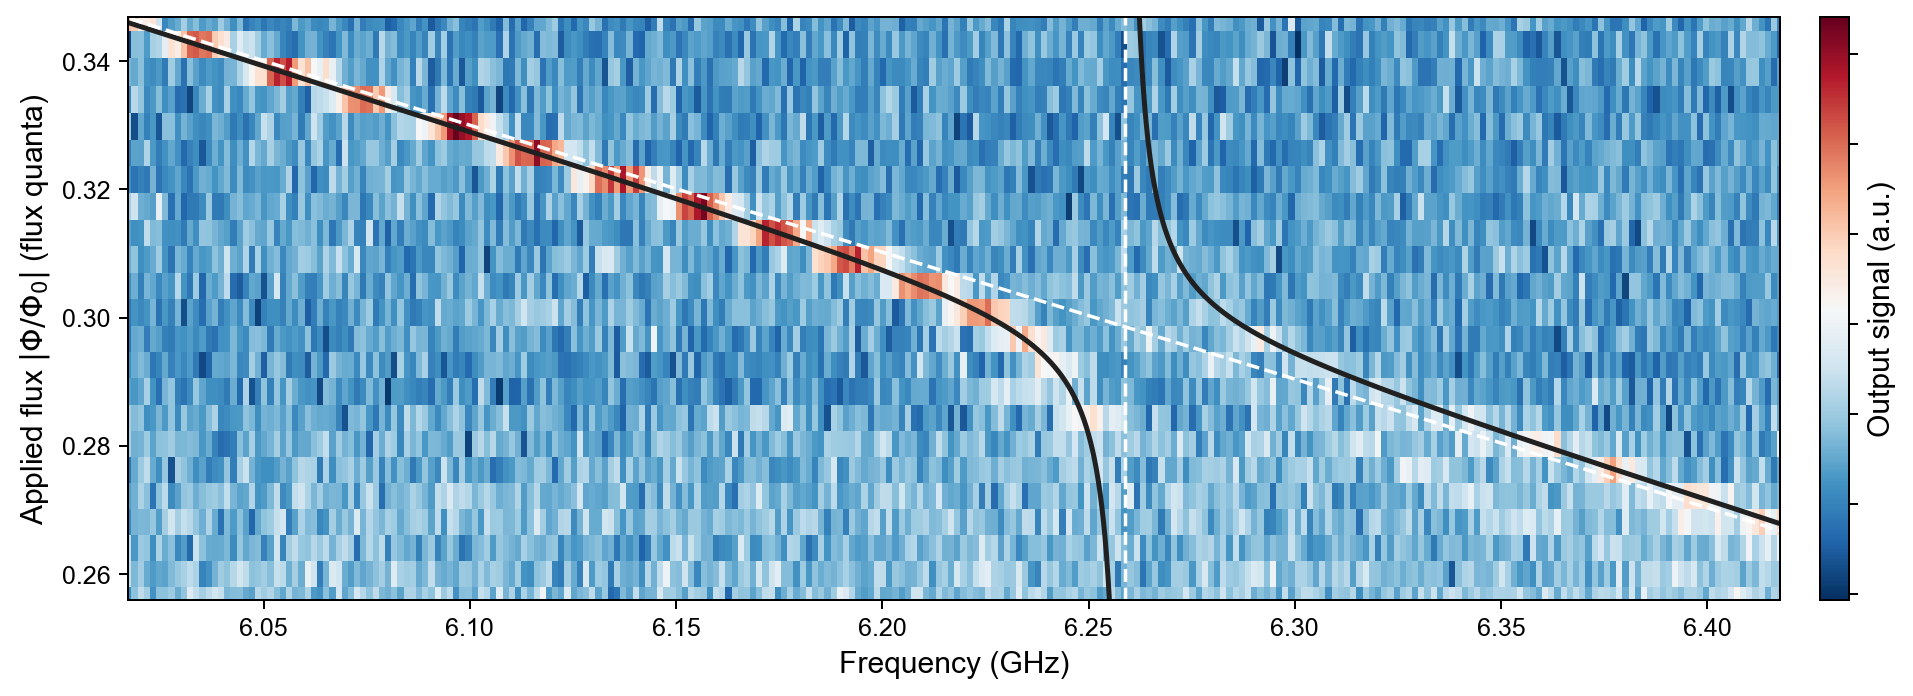

In [10]:
def plot_final_figure(flux, frequency_hz, signal, peak_flux, peak_frequency_hz, parameters):
    """Plot the publication figure and optionally export it as a PDF."""
    dense_flux = np.linspace(flux.min(), flux.max(), 3000)
    bare_hz, lower_hz, upper_hz = coupled_branches(dense_flux, parameters)
    bare_axis_hz = coupled_branches(flux, parameters)[0]
    bare_peak_hz = coupled_branches(peak_flux, parameters)[0]

    flux_phi0 = bare_frequency_to_phi0(bare_axis_hz)
    peak_flux_phi0 = bare_frequency_to_phi0(bare_peak_hz)
    dense_flux_phi0 = bare_frequency_to_phi0(bare_hz)
    row_order = np.argsort(flux_phi0)

    mode_hz = parameters[-2]
    with plt.rc_context(
        {
            "font.family": "sans-serif",
            "font.sans-serif": [FONT],
            "font.size": 11,
            "axes.labelsize": 12,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "pdf.fonttype": 42,
        }
    ):
        fig, ax = plt.subplots(figsize=FIGURE_SIZE, dpi=FIGURE_DPI)
        mesh = ax.pcolormesh(
            frequency_hz / 1e9,
            flux_phi0[row_order],
            signal[row_order],
            shading="auto",
            cmap=COLORMAP,
            rasterized=True,
        )
        colorbar = fig.colorbar(mesh, ax=ax, pad=0.02)
        colorbar.set_label("Output signal (a.u.)")
        colorbar.ax.tick_params(labelright=False, labelleft=False)

        if SHOW_SELECTED_POINTS:
            ax.scatter(
                peak_frequency_hz / 1e9,
                peak_flux_phi0,
                s=25,
                facecolors="white",
                edgecolors="black",
                linewidths=0.8,
                zorder=5,
                label="selected fit points",
            )

        ax.plot(lower_hz / 1e9, dense_flux_phi0, color=FIT_COLOR, linewidth=2, label="fit")
        ax.plot(upper_hz / 1e9, dense_flux_phi0, color=FIT_COLOR, linewidth=2)
        ax.plot(
            bare_hz / 1e9,
            dense_flux_phi0,
            color=BARE_COLOR,
            linestyle="--",
            linewidth=1.4,
            label="bare qubit",
        )
        ax.axvline(
            mode_hz / 1e9,
            color=MODE_COLOR,
            linestyle="--",
            linewidth=1.4,
            label="bare mode",
        )
        ax.set(
            xlim=(frequency_hz.min() / 1e9, frequency_hz.max() / 1e9),
            ylim=(flux_phi0.min(), flux_phi0.max()),
            xlabel="Frequency (GHz)",
            ylabel=r"Applied flux $|\Phi/\Phi_0|$ (flux quanta)",
        )
        ax.margins(x=0, y=0)
        if SHOW_LEGEND:
            ax.legend(loc="best", framealpha=0.9)
        fig.tight_layout()

        if EXPORT_PDF:
            fig.savefig(OUTPUT_PDF, format="pdf", bbox_inches="tight")
            print(f"Saved: {OUTPUT_PDF}")
        plt.show()

plot_final_figure(
    flux,
    frequency_hz,
    signal,
    peak_flux,
    peak_frequency_hz,
    parameters,
)
